In [1]:
from datasets import load_dataset

ds = load_dataset("clapAI/MultiLingualSentiment")

data/train-00002-of-00003.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

c:\Users\ADMIN\.conda\envs\langchain_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\datasets--clapAI--MultiLingualSentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/validation-00000-of-00001.parquet:   0%|          | 0.00/99.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/98.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3147478 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/393435 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/393436 [00:00<?, ? examples/s]

In [19]:
print(ds["train"][0])

{'text': 'A good environment with good food. Price is reasonable.', 'label': 'positive', 'source': 'https://www.kaggle.com/datasets/choonkhonng/malaysia-restaurant-review-datasets', 'domain': 'restaurant reviews ', 'language': 'en'}


In [21]:
# Filter dataset to keep only English texts
print("Original dataset sizes:")
print(f"Train: {len(ds['train'])}, Test: {len(ds['test'])}")

# Filter to English only
ds_en_train = ds['train'].filter(lambda x: x.get('language', x.get('lang')) == 'en')
ds_en_test = ds['test'].filter(lambda x: x.get('language', x.get('lang')) == 'en')

print("\nFiltered dataset sizes (English only):")
print(f"Train: {len(ds_en_train)}, Test: {len(ds_en_test)}")

# Update ds to use only English splits
from datasets import DatasetDict
ds = DatasetDict({
    'train': ds_en_train,
    'test': ds_en_test
})

Original dataset sizes:
Train: 3147478, Test: 393436


Filter:   0%|          | 0/3147478 [00:00<?, ? examples/s]

Filter:   0%|          | 0/393436 [00:00<?, ? examples/s]


Filtered dataset sizes (English only):
Train: 1215709, Test: 151926


In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 3147478
    })
    validation: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 393435
    })
    test: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 393436
    })
})


In [22]:
print(ds['train'][100])

{'text': "Don't stay here on the weekend unless you are ready for a sleepless night. We arrived on a Thursday for a conference and found the hotel clean, in a great location, reasonably priced and safe.\nAll that changed on Friday night. Apparently there was some track meet going on in Austin and all the hooligans decided to stay in our hotel. We were next door and across the hallway from some thugs who kept SLAMMING their doors all night. Until 4 am, they slammed doors, screamed, hollered, and partied it up. We called the front desk at least six times, and they refused to call the police for noise. We begged them to do so, but they refused, stating something lame like 'we need a warrant' which is an utter and total falsehood. Refusing to provide us with service is the reason why I will never stay here again. Not only that but there was vomit in the elevator and on the lobby floors when we checked out.\nI realize it's not the hotel's fault that people were noisy but the way they dealt 

In [23]:
# Explore dataset structure
print("Dataset features:", ds['train'].features)
print("Number of samples in train:", len(ds['train']))
print("Number of samples in test:", len(ds['test']))

Dataset features: {'text': Value('string'), 'label': Value('string'), 'source': Value('string'), 'domain': Value('string'), 'language': Value('string')}
Number of samples in train: 1215709
Number of samples in test: 151926


1. NULL VALUES CHECK
train: 0 null/empty texts out of 1215709
test: 0 null/empty texts out of 151926

2. CLASS DISTRIBUTION

Training set:
  Label negative: 442928 (36.43%)
  Label neutral: 360246 (29.63%)
  Label positive: 412535 (33.93%)

Test set:
  Label negative: 55447 (36.50%)
  Label neutral: 44993 (29.62%)
  Label positive: 51486 (33.89%)

3. TEXT LENGTH ANALYSIS

Training set text length (words):
  Min: 1, Max: 3213
  Mean: 84.22, Median: 42.00
  Std: 112.08

Test set text length (words):
  Min: 1, Max: 2115
  Mean: 84.13, Median: 42.00
  Std: 111.29

4. SAMPLE TEXTS PER CLASS

Label negative: I could not make it through these books. Each one was worse than the other. I like this kind of genre but these were poorly written and not worth the ...

Label neutral: Çoğunlukla kültürel veya sanatsal faaliyetler için kullanılan bir terimdir....

Label positive: A good environment with good food. Price is reasonable....


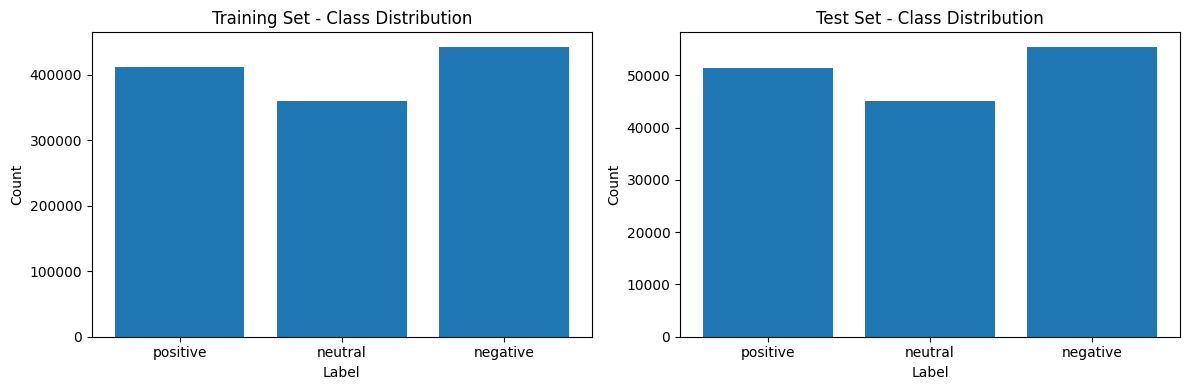

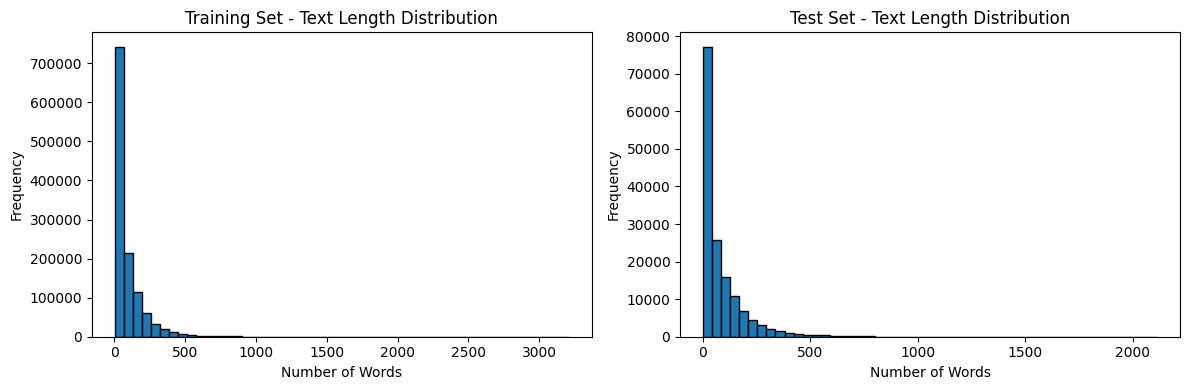

In [24]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Check for null values
print("=" * 50)
print("1. NULL VALUES CHECK")
print("=" * 50)
for split in ds.keys():
    null_count = sum(1 for item in ds[split] if item['text'] is None or item['text'].strip() == '')
    print(f"{split}: {null_count} null/empty texts out of {len(ds[split])}")

# 2. Class distribution
print("\n" + "=" * 50)
print("2. CLASS DISTRIBUTION")
print("=" * 50)
train_labels = [item['label'] for item in ds['train']]
test_labels = [item['label'] for item in ds['test']]

train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)

print("\nTraining set:")
for label, count in sorted(train_label_counts.items()):
    percentage = (count / len(train_labels)) * 100
    print(f"  Label {label}: {count} ({percentage:.2f}%)")

print("\nTest set:")
for label, count in sorted(test_label_counts.items()):
    percentage = (count / len(test_labels)) * 100
    print(f"  Label {label}: {count} ({percentage:.2f}%)")

# 3. Text length analysis
print("\n" + "=" * 50)
print("3. TEXT LENGTH ANALYSIS")
print("=" * 50)
train_lengths = [len(item['text'].split()) for item in ds['train']]
test_lengths = [len(item['text'].split()) for item in ds['test']]

print(f"\nTraining set text length (words):")
print(f"  Min: {min(train_lengths)}, Max: {max(train_lengths)}")
print(f"  Mean: {np.mean(train_lengths):.2f}, Median: {np.median(train_lengths):.2f}")
print(f"  Std: {np.std(train_lengths):.2f}")

print(f"\nTest set text length (words):")
print(f"  Min: {min(test_lengths)}, Max: {max(test_lengths)}")
print(f"  Mean: {np.mean(test_lengths):.2f}, Median: {np.median(test_lengths):.2f}")
print(f"  Std: {np.std(test_lengths):.2f}")

# 4. Sample texts per class
print("\n" + "=" * 50)
print("4. SAMPLE TEXTS PER CLASS")
print("=" * 50)
for label in sorted(set(train_labels)):
    sample = next(item for item in ds['train'] if item['label'] == label)
    print(f"\nLabel {label}: {sample['text'][:150]}...")

# 5. Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_label_counts.keys(), train_label_counts.values())
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

axes[1].bar(test_label_counts.keys(), test_label_counts.values())
axes[1].set_title('Test Set - Class Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# 6. Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_lengths, bins=50, edgecolor='black')
axes[0].set_title('Training Set - Text Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

axes[1].hist(test_lengths, bins=50, edgecolor='black')
axes[1].set_title('Test Set - Text Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [25]:
# Import necessary libraries
import re
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [32]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    # words = [word for word in words if word not in stop_words]
    text = " ".join(words)
    return text

train_texts = [
    preprocess_text(item['text'])
    for item in ds['train']
]
train_labels = [
    item['label']
    for item in ds['train']
]
test_texts = [
    preprocess_text(item['text'])
    for item in ds['test']
]
test_labels = [
    item['label']
    for item in ds['test']
]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
print(ds['train'][0])
print(train_texts[0])
print(train_labels[0])

{'text': 'A good environment with good food. Price is reasonable.', 'label': 'positive', 'source': 'https://www.kaggle.com/datasets/choonkhonng/malaysia-restaurant-review-datasets', 'domain': 'restaurant reviews ', 'language': 'en'}
a good environment with good food price is reasonable
positive


In [34]:
# Generate BoW
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(train_texts)
X_test_bow = vectorizer.transform(test_texts)

print("BoW shape:", X_train_bow.shape)

BoW shape: (1215709, 989219)


In [35]:
# Generate TF-IDF
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_bow)
X_test_tfidf = tfidf_transformer.transform(X_test_bow)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (1215709, 989219)


In [36]:
# Train Logistic Regression
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, train_labels)
lr_train_time = time.time() - start_time

# Train Naive Bayes
start_time = time.time()
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, train_labels)
nb_train_time = time.time() - start_time

print(f"Logistic Regression training time: {lr_train_time:.4f} seconds")
print(f"Naive Bayes training time: {nb_train_time:.4f} seconds")

Logistic Regression training time: 1019.3709 seconds
Naive Bayes training time: 3.0267 seconds


In [37]:
# Evaluate models
lr_pred = lr_model.predict(X_test_tfidf)
nb_pred = nb_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(test_labels, lr_pred)
lr_f1 = f1_score(test_labels, lr_pred, average='weighted')

nb_accuracy = accuracy_score(test_labels, nb_pred)
nb_f1 = f1_score(test_labels, nb_pred, average='weighted')

print("Logistic Regression:")
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"  Training Time: {lr_train_time:.4f} seconds")

print("\nNaive Bayes:")
print(f"  Accuracy: {nb_accuracy:.4f}")
print(f"  F1-Score: {nb_f1:.4f}")
print(f"  Training Time: {nb_train_time:.4f} seconds")

Logistic Regression:
  Accuracy: 0.7575
  F1-Score: 0.7566
  Training Time: 1019.3709 seconds

Naive Bayes:
  Accuracy: 0.6925
  F1-Score: 0.6806
  Training Time: 3.0267 seconds
